In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0857.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0816.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0835.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0889.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0834.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0804.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0802.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0872.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0866.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0846.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0884.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0876.png
/kaggle/input/datasets/shara

In [2]:
# ============================================================
# STEP 1 — PROJECT SETUP
# ============================================================

import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import structural_similarity as ssim

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print("AI SUPER-RESOLUTION & IMAGE RESTORATION")
print("=" * 50)
print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    print("GPU             : Not available")

AI SUPER-RESOLUTION & IMAGE RESTORATION
PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


# Configuration

In [3]:
# ============================================================
# STEP 2 — PROJECT CONFIGURATION
# ============================================================

# IMPORTANT:
# We will change this after selecting the Kaggle dataset.
DATASET_DIR = "/kaggle/input/datasets/sharansmenon/div2k"

# Where Kaggle will save our generated outputs
OUTPUT_DIR = "/kaggle/working/restoration_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Image configuration
IMG_SIZE = 128
SCALE = 2

# Training configuration
BATCH_SIZE = 16
SRCNN_EPOCHS = 10
COLOR_EPOCHS = 10

LEARNING_RATE = 1e-3

print("Configuration")
print("-" * 50)
print("Dataset :", DATASET_DIR)
print("Output  :", OUTPUT_DIR)
print("Size    :", IMG_SIZE)
print("Scale   :", SCALE)
print("Batch   :", BATCH_SIZE)
print("LR      :", LEARNING_RATE)

Configuration
--------------------------------------------------
Dataset : /kaggle/input/datasets/sharansmenon/div2k
Output  : /kaggle/working/restoration_results
Size    : 128
Scale   : 2
Batch   : 16
LR      : 0.001


In [4]:
# ============================================================
# STEP 3 — FIND DATASET IMAGES
# ============================================================

EXTENSIONS = (
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.bmp",
    "*.tif",
    "*.tiff"
)

image_paths = []

for ext in EXTENSIONS:
    image_paths.extend(
        glob.glob(
            os.path.join(DATASET_DIR, "**", ext),
            recursive=True
        )
    )

image_paths = sorted(list(set(image_paths)))

print("Total images found:", len(image_paths))
print()

for path in image_paths[:10]:
    print(path)

Total images found: 900

/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0001.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0002.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0003.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0004.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0005.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0006.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0007.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0008.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0009.png
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0010.png


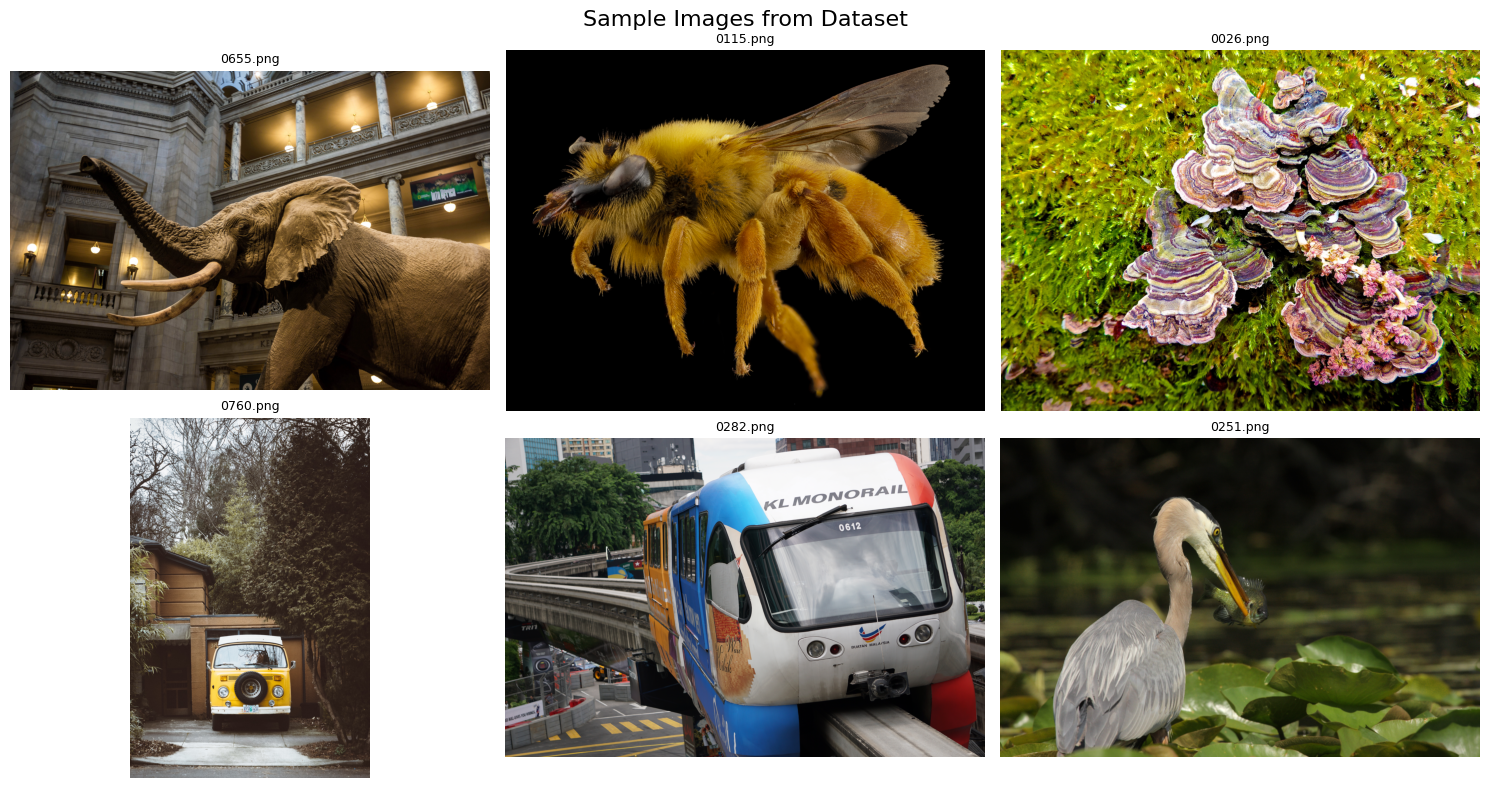

In [5]:
# ============================================================
# STEP 4 — VISUALIZE DATASET
# ============================================================

sample_count = min(6, len(image_paths))

samples = random.sample(image_paths, sample_count)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, path in zip(axes, samples):

    image = Image.open(path).convert("RGB")

    ax.imshow(image)
    ax.set_title(
        os.path.basename(path),
        fontsize=9
    )
    ax.axis("off")

plt.suptitle(
    "Sample Images from Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# STEP 5 — CONFIGURE TRAIN / VALIDATION DATASETS
# ============================================================

TRAIN_DIR = "/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR"

VAL_DIR = "/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR"

print("Training directory:")
print(TRAIN_DIR)

print("\nValidation directory:")
print(VAL_DIR)

Training directory:
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR

Validation directory:
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR


In [7]:
# ============================================================
# STEP 5.1 — FIND TRAINING AND VALIDATION IMAGES
# ============================================================

def find_images(directory):

    extensions = (
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.bmp",
        "*.tif",
        "*.tiff"
    )

    paths = []

    for ext in extensions:
        paths.extend(
            glob.glob(
                os.path.join(directory, "**", ext),
                recursive=True
            )
        )

    return sorted(list(set(paths)))


train_paths = find_images(TRAIN_DIR)
val_paths = find_images(VAL_DIR)

print("=" * 50)
print("DIV2K DATASET")
print("=" * 50)

print("Training images   :", len(train_paths))
print("Validation images :", len(val_paths))

print("\nFirst training image:")
print(train_paths[0])

print("\nFirst validation image:")
print(val_paths[0])

DIV2K DATASET
Training images   : 800
Validation images : 100

First training image:
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_train_HR/DIV2K_train_HR/0001.png

First validation image:
/kaggle/input/datasets/sharansmenon/div2k/DIV2K_valid_HR/DIV2K_valid_HR/0801.png


# Create SRCNN Dataset Class

In [21]:
# ============================================================
# STEP 6 — IMPROVED SRCNN DATASET
# RANDOM HR PATCHES
# ============================================================

class SRCNNPatchDataset(Dataset):

    def __init__(
        self,
        image_paths,
        patch_size=128,
        scale=2,
        patches_per_image=10
    ):

        self.image_paths = image_paths
        self.patch_size = patch_size
        self.scale = scale
        self.patches_per_image = patches_per_image

    def __len__(self):

        return len(self.image_paths) * self.patches_per_image

    def __getitem__(self, idx):

        # ----------------------------------------------------
        # Select image
        # ----------------------------------------------------

        image_index = idx // self.patches_per_image

        image_path = self.image_paths[image_index]

        image = Image.open(
            image_path
        ).convert("RGB")

        image = np.array(image).astype(
            np.float32
        ) / 255.0

        height, width, _ = image.shape

        # ----------------------------------------------------
        # Make sure image is large enough
        # ----------------------------------------------------

        if height < self.patch_size or width < self.patch_size:

            image = cv2.resize(
                image,
                (
                    max(width, self.patch_size),
                    max(height, self.patch_size)
                ),
                interpolation=cv2.INTER_CUBIC
            )

            height, width, _ = image.shape

        # ----------------------------------------------------
        # Random crop
        # ----------------------------------------------------

        top = random.randint(
            0,
            height - self.patch_size
        )

        left = random.randint(
            0,
            width - self.patch_size
        )

        hr_rgb = image[
            top:top + self.patch_size,
            left:left + self.patch_size
        ]

        # ----------------------------------------------------
        # RGB → Y channel
        # ----------------------------------------------------

        hr_y = (
            0.299 * hr_rgb[:, :, 0]
            + 0.587 * hr_rgb[:, :, 1]
            + 0.114 * hr_rgb[:, :, 2]
        )

        # ----------------------------------------------------
        # Generate LR image
        # ----------------------------------------------------

        lr_size = self.patch_size // self.scale

        lr_y = cv2.resize(
            hr_y,
            (lr_size, lr_size),
            interpolation=cv2.INTER_AREA
        )

        # ----------------------------------------------------
        # Bicubic upsampling
        # ----------------------------------------------------

        bicubic_y = cv2.resize(
            lr_y,
            (self.patch_size, self.patch_size),
            interpolation=cv2.INTER_CUBIC
        )

        # ----------------------------------------------------
        # Convert to tensors
        # ----------------------------------------------------

        input_tensor = torch.from_numpy(
            bicubic_y.copy()
        ).float().unsqueeze(0)

        target_tensor = torch.from_numpy(
            hr_y.copy()
        ).float().unsqueeze(0)

        return input_tensor, target_tensor

In [22]:
# ============================================================
# STEP 6.2 — CREATE DATASETS
# ============================================================

train_dataset = SRCNNDataset(
    train_paths,
    img_size=IMG_SIZE,
    scale=SCALE
)

val_dataset = SRCNNDataset(
    val_paths,
    img_size=IMG_SIZE,
    scale=SCALE
)

print("=" * 50)
print("SRCNN DATASETS")
print("=" * 50)

print("Training samples   :", len(train_dataset))
print("Validation samples :", len(val_dataset))

SRCNN DATASETS
Training samples   : 800
Validation samples : 100


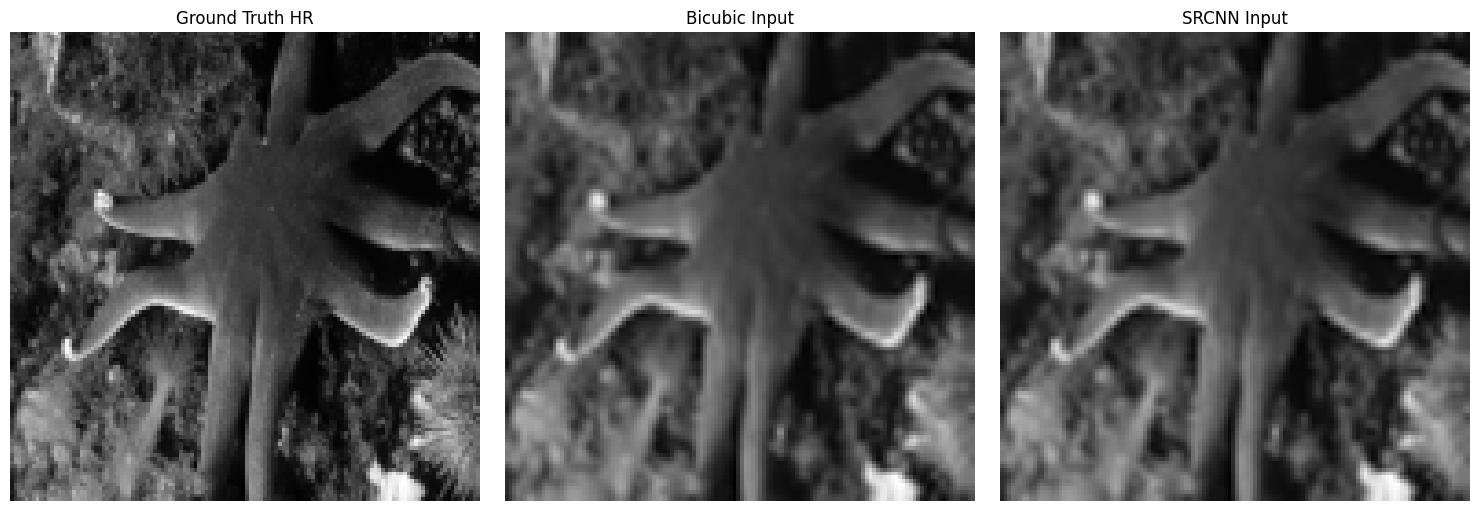

In [23]:
# ============================================================
# STEP 6.3 — VISUALIZE SRCNN TRAINING PAIR
# ============================================================

lr_tensor, hr_tensor = train_dataset[0]

lr_image = lr_tensor.squeeze().numpy()
hr_image = hr_tensor.squeeze().numpy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    hr_image,
    cmap="gray"
)
axes[0].set_title("Ground Truth HR")

axes[1].imshow(
    cv2.resize(
        lr_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    ),
    cmap="gray"
)
axes[1].set_title("Bicubic Input")

axes[2].imshow(
    lr_image,
    cmap="gray"
)
axes[2].set_title("SRCNN Input")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

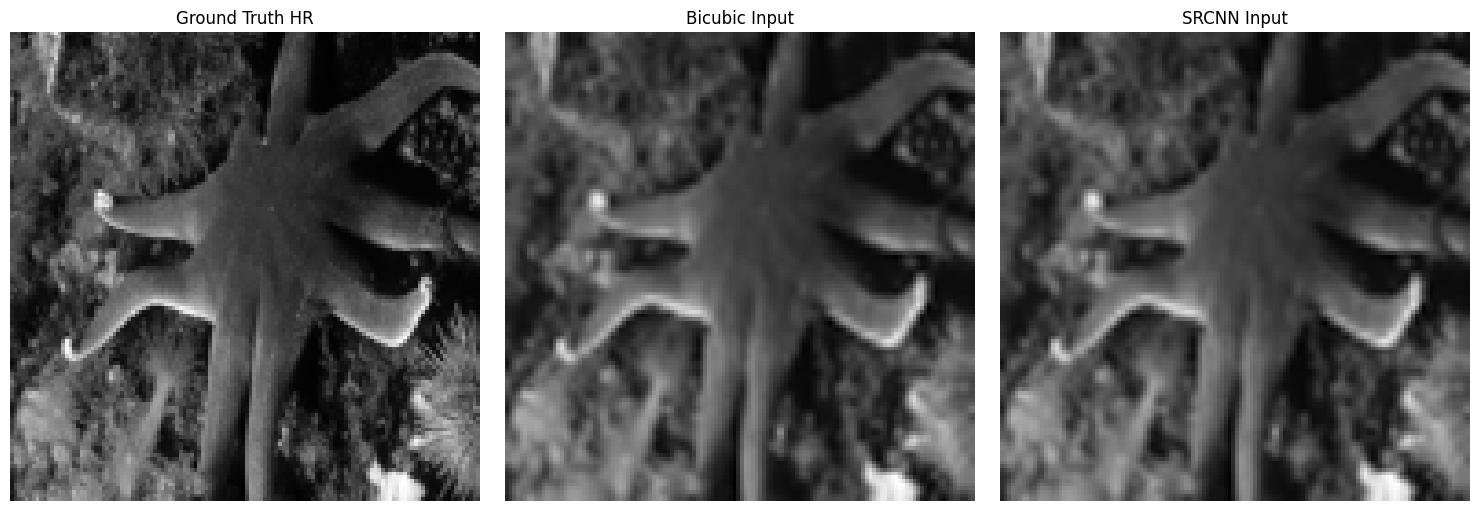

In [24]:
# ============================================================
# STEP 6.3 — VISUALIZE SRCNN TRAINING PAIR
# ============================================================

lr_tensor, hr_tensor = train_dataset[0]

lr_image = lr_tensor.squeeze().numpy()
hr_image = hr_tensor.squeeze().numpy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    hr_image,
    cmap="gray"
)
axes[0].set_title("Ground Truth HR")

axes[1].imshow(
    cv2.resize(
        lr_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    ),
    cmap="gray"
)
axes[1].set_title("Bicubic Input")

axes[2].imshow(
    lr_image,
    cmap="gray"
)
axes[2].set_title("SRCNN Input")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# STEP 6.4 — DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 50)
print("DATALOADERS")
print("=" * 50)

print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))

DATALOADERS
Training batches   : 50
Validation batches : 7


In [26]:
# ============================================================
# STEP 7 — SRCNN ARCHITECTURE
# ============================================================

class SRCNN(nn.Module):

    def __init__(self):
        super(SRCNN, self).__init__()

        # Feature extraction
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=9,
            padding=4
        )

        # Non-linear mapping
        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=32,
            kernel_size=5,
            padding=2
        )

        # Reconstruction
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=1,
            kernel_size=5,
            padding=2
        )

    def forward(self, x):

        x = F.relu(self.conv1(x))

        x = F.relu(self.conv2(x))

        x = self.conv3(x)

        return x


# Create model
model = SRCNN().to(DEVICE)

print(model)

SRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


In [27]:
# ============================================================
# STEP 7.2 — MODEL PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 50)
print("SRCNN MODEL INFORMATION")
print("=" * 50)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

SRCNN MODEL INFORMATION
Total parameters     : 57,281
Trainable parameters : 57,281


# Verifying Tensor Dimension

In [28]:
# ============================================================
# STEP 7.3 — VERIFY INPUT / OUTPUT DIMENSIONS
# ============================================================

# Get one batch
sample_input, sample_target = next(iter(train_loader))

print("Before model")
print("-" * 50)

print("Input shape  :", sample_input.shape)
print("Target shape :", sample_target.shape)

# Move input to GPU/CPU
sample_input = sample_input.to(DEVICE)

# Forward pass
with torch.no_grad():

    sample_output = model(sample_input)

print("\nAfter model")
print("-" * 50)

print("Output shape :", sample_output.shape)

Before model
--------------------------------------------------
Input shape  : torch.Size([16, 1, 128, 128])
Target shape : torch.Size([16, 1, 128, 128])

After model
--------------------------------------------------
Output shape : torch.Size([16, 1, 128, 128])


# Loss and optimizer

In [30]:
# ============================================================
# STEP 8.1 — LOSS FUNCTION AND OPTIMIZER
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("=" * 50)
print("TRAINING CONFIGURATION")
print("=" * 50)

print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", LEARNING_RATE)
print("Epochs        :", SRCNN_EPOCHS)
print("Device        :", DEVICE)

TRAINING CONFIGURATION
Loss function : MSELoss()
Optimizer     : Adam
Learning rate : 0.001
Epochs        : 10
Device        : cuda


In [31]:
# ============================================================
# STEP 8.2 — SRCNN TRAINING LOOP
# ============================================================

train_losses = []
val_losses = []

best_val_loss = float("inf")

best_model_path = os.path.join(
    OUTPUT_DIR,
    "srcnn_best.pth"
)

print("=" * 60)
print("STARTING SRCNN TRAINING")
print("=" * 60)

for epoch in range(SRCNN_EPOCHS):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()

    running_train_loss = 0.0

    for inputs, targets in train_loader:

        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, targets)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, targets in val_loader:

            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            running_val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = (
        running_val_loss / len(val_loader.dataset)
    )

    # Store losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        saved = "  ← best"

    else:
        saved = ""

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{SRCNN_EPOCHS}] "
        f"| Train Loss: {epoch_train_loss:.6f} "
        f"| Val Loss: {epoch_val_loss:.6f}"
        f"{saved}"
    )

print("\nTraining complete.")
print("Best model saved to:")
print(best_model_path)

STARTING SRCNN TRAINING
Epoch [01/10] | Train Loss: 0.021770 | Val Loss: 0.004820  ← best
Epoch [02/10] | Train Loss: 0.003386 | Val Loss: 0.003192  ← best
Epoch [03/10] | Train Loss: 0.002829 | Val Loss: 0.002984  ← best
Epoch [04/10] | Train Loss: 0.002714 | Val Loss: 0.002883  ← best
Epoch [05/10] | Train Loss: 0.002676 | Val Loss: 0.002857  ← best
Epoch [06/10] | Train Loss: 0.002622 | Val Loss: 0.002818  ← best
Epoch [07/10] | Train Loss: 0.002588 | Val Loss: 0.002805  ← best
Epoch [08/10] | Train Loss: 0.002783 | Val Loss: 0.002849
Epoch [09/10] | Train Loss: 0.002567 | Val Loss: 0.002770  ← best
Epoch [10/10] | Train Loss: 0.002537 | Val Loss: 0.002753  ← best

Training complete.
Best model saved to:
/kaggle/working/restoration_results/srcnn_best.pth


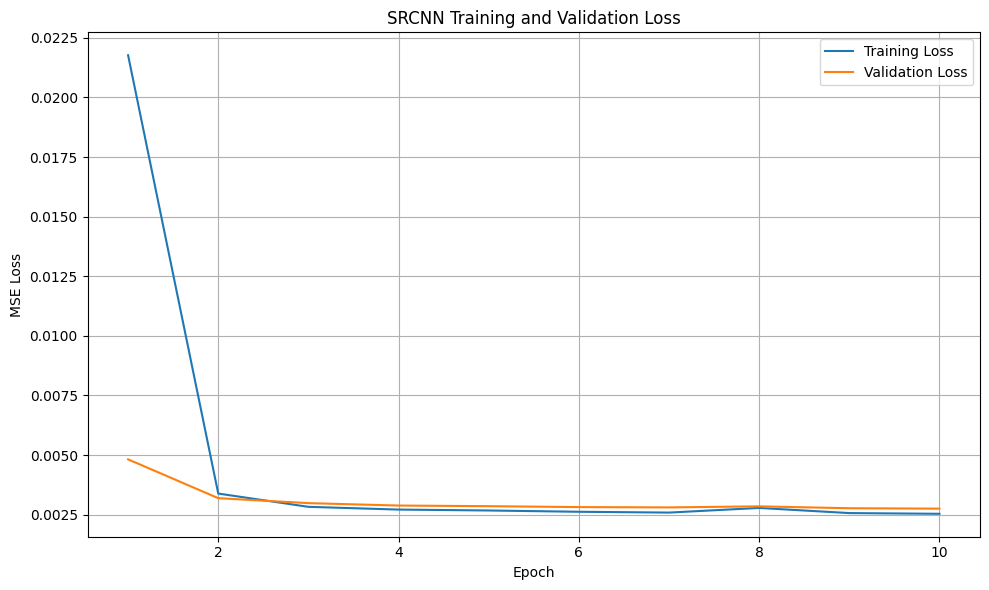

In [33]:
# ============================================================
# STEP 8.3 — TRAINING / VALIDATION LOSS CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, SRCNN_EPOCHS + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, SRCNN_EPOCHS + 1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SRCNN Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# STEP 8.4 — LOAD BEST SRCNN MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)
model.eval()

print("Best SRCNN model loaded successfully.")
print("Checkpoint:", best_model_path)

Best SRCNN model loaded successfully.
Checkpoint: /kaggle/working/restoration_results/srcnn_best.pth


# Save What SRCNN Learned

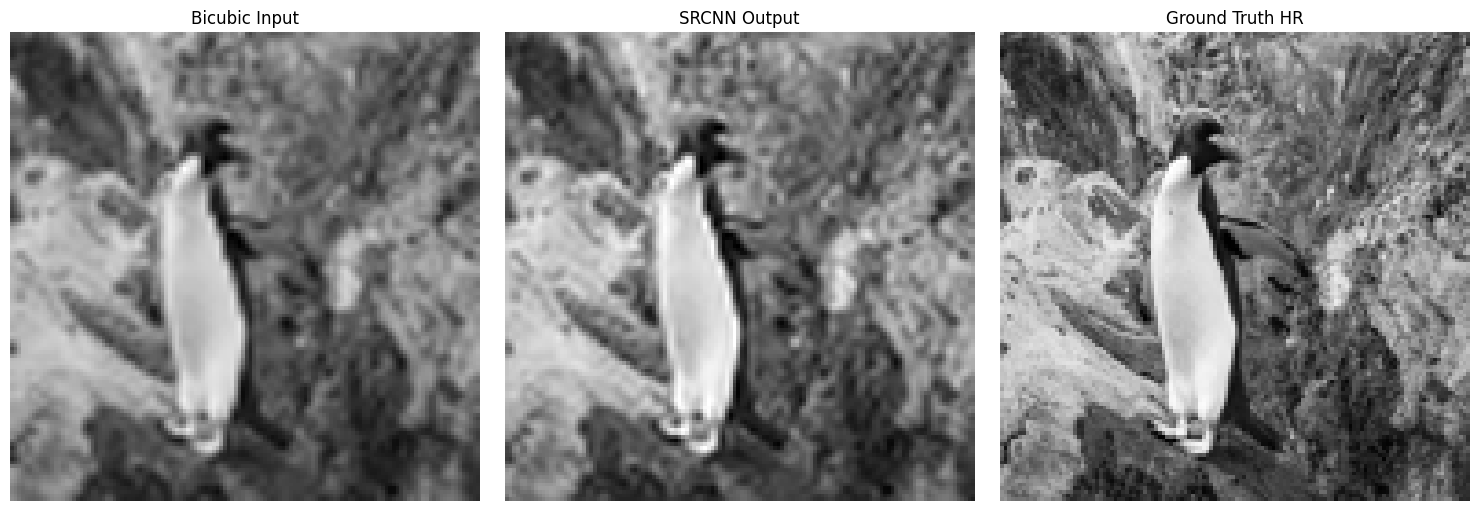

In [35]:
# ============================================================
# STEP 8.5 — VISUALIZE TRAINED SRCNN
# ============================================================

inputs, targets = next(iter(val_loader))

inputs = inputs.to(DEVICE)

with torch.no_grad():
    outputs = model(inputs)

input_image = inputs[0].cpu().squeeze().numpy()
output_image = outputs[0].cpu().squeeze().numpy()
target_image = targets[0].squeeze().numpy()

# Keep values in valid image range
output_image = np.clip(
    output_image,
    0,
    1
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    input_image,
    cmap="gray"
)
axes[0].set_title("Bicubic Input")

axes[1].imshow(
    output_image,
    cmap="gray"
)
axes[1].set_title("SRCNN Output")

axes[2].imshow(
    target_image,
    cmap="gray"
)
axes[2].set_title("Ground Truth HR")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# PSNR + SSIM Evaluation

In [36]:
# ============================================================
# STEP 9 — PSNR + SSIM EVALUATION
# ============================================================

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

model.eval()

bicubic_psnr = []
srcnn_psnr = []

bicubic_ssim = []
srcnn_ssim = []

with torch.no_grad():

    for inputs, targets in val_loader:

        inputs = inputs.to(DEVICE)

        outputs = model(inputs)

        inputs_np = inputs.cpu().numpy()
        outputs_np = outputs.cpu().numpy()
        targets_np = targets.numpy()

        for i in range(inputs_np.shape[0]):

            bicubic = np.clip(inputs_np[i, 0], 0, 1)
            sr = np.clip(outputs_np[i, 0], 0, 1)
            hr = np.clip(targets_np[i, 0], 0, 1)

            # PSNR
            bicubic_psnr.append(
                peak_signal_noise_ratio(
                    hr,
                    bicubic,
                    data_range=1.0
                )
            )

            srcnn_psnr.append(
                peak_signal_noise_ratio(
                    hr,
                    sr,
                    data_range=1.0
                )
            )

            # SSIM
            bicubic_ssim.append(
                structural_similarity(
                    hr,
                    bicubic,
                    data_range=1.0
                )
            )

            srcnn_ssim.append(
                structural_similarity(
                    hr,
                    sr,
                    data_range=1.0
                )
            )


# ------------------------------------------------------------
# Calculate averages
# ------------------------------------------------------------

mean_bicubic_psnr = np.mean(bicubic_psnr)
mean_srcnn_psnr = np.mean(srcnn_psnr)

mean_bicubic_ssim = np.mean(bicubic_ssim)
mean_srcnn_ssim = np.mean(srcnn_ssim)

print("=" * 60)
print("SRCNN SUPER-RESOLUTION EVALUATION")
print("=" * 60)

print(f"{'Metric':<15} {'Bicubic':>15} {'SRCNN':>15}")
print("-" * 45)

print(
    f"{'PSNR (dB)':<15} "
    f"{mean_bicubic_psnr:>15.4f} "
    f"{mean_srcnn_psnr:>15.4f}"
)

print(
    f"{'SSIM':<15} "
    f"{mean_bicubic_ssim:>15.4f} "
    f"{mean_srcnn_ssim:>15.4f}"
)

print("-" * 45)

print(
    f"PSNR improvement : "
    f"{mean_srcnn_psnr - mean_bicubic_psnr:+.4f} dB"
)

print(
    f"SSIM improvement : "
    f"{mean_srcnn_ssim - mean_bicubic_ssim:+.4f}"
)

SRCNN SUPER-RESOLUTION EVALUATION
Metric                  Bicubic           SRCNN
---------------------------------------------
PSNR (dB)               26.1938         26.4896
SSIM                     0.8600          0.8725
---------------------------------------------
PSNR improvement : +0.2958 dB
SSIM improvement : +0.0125


In [37]:
#Save the metrics
# ============================================================
# STEP 9.1 — SAVE EVALUATION RESULTS
# ============================================================

import pandas as pd

metrics_df = pd.DataFrame({
    "Method": ["Bicubic", "SRCNN"],
    "PSNR_dB": [
        mean_bicubic_psnr,
        mean_srcnn_psnr
    ],
    "SSIM": [
        mean_bicubic_ssim,
        mean_srcnn_ssim
    ]
})

metrics_path = os.path.join(
    OUTPUT_DIR,
    "srcnn_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Metrics saved to:")
print(metrics_path)

display(metrics_df)

Metrics saved to:
/kaggle/working/restoration_results/srcnn_metrics.csv


,Method,PSNR_dB,SSIM
0,Bicubic,26.193765,0.860044
1,SRCNN,26.489552,0.872542


# Denoising

In [38]:
# ============================================================
# STEP 10 — DENOISING
# ============================================================

def denoise_image(image):

    """
    Apply Fast Non-Local Means Denoising
    to a grayscale image.
    """

    image_uint8 = np.clip(
        image * 255,
        0,
        255
    ).astype(np.uint8)

    denoised = cv2.fastNlMeansDenoising(
        image_uint8,
        None,
        h=10,
        templateWindowSize=7,
        searchWindowSize=21
    )

    return denoised.astype(np.float32) / 255.0

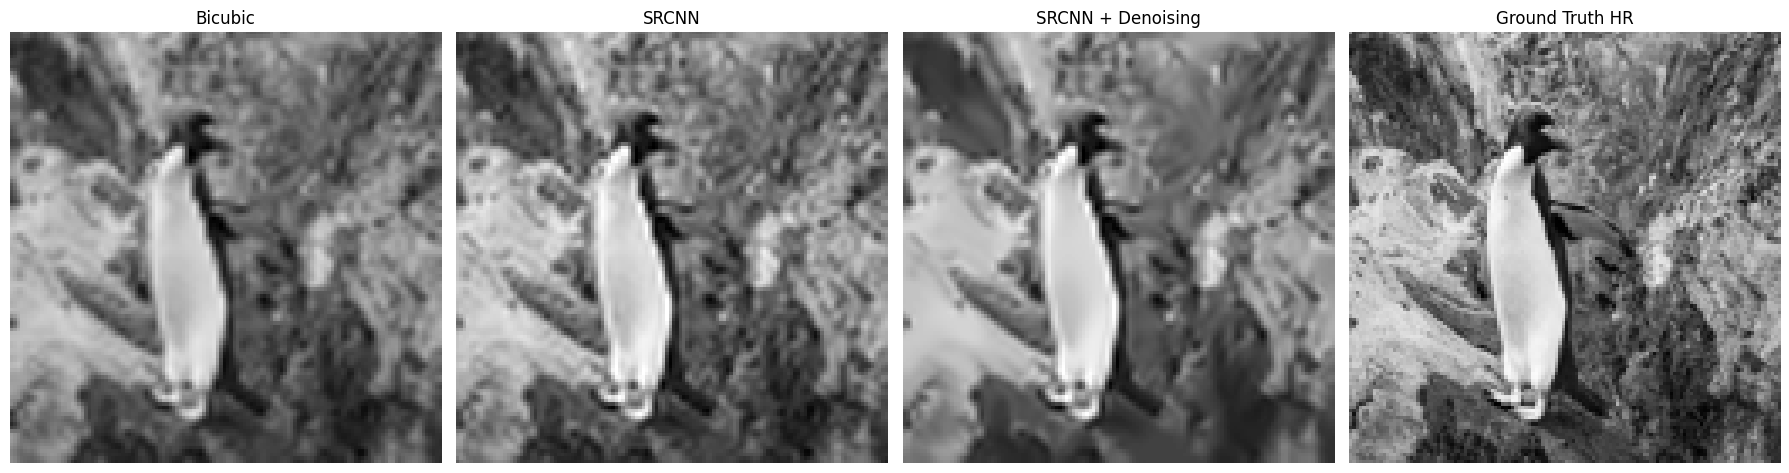

In [39]:
# ============================================================
# STEP 10.1 — SRCNN + DENOISING VISUALIZATION
# ============================================================

inputs, targets = next(iter(val_loader))

inputs_gpu = inputs.to(DEVICE)

with torch.no_grad():
    outputs = model(inputs_gpu)

bicubic = inputs[0, 0].numpy()
sr = np.clip(
    outputs[0, 0].cpu().numpy(),
    0,
    1
)

denoised = denoise_image(sr)

hr = targets[0, 0].numpy()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

axes[0].imshow(
    bicubic,
    cmap="gray"
)
axes[0].set_title("Bicubic")

axes[1].imshow(
    sr,
    cmap="gray"
)
axes[1].set_title("SRCNN")

axes[2].imshow(
    denoised,
    cmap="gray"
)
axes[2].set_title("SRCNN + Denoising")

axes[3].imshow(
    hr,
    cmap="gray"
)
axes[3].set_title("Ground Truth HR")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# STEP 11 — COLORIZATION DATASET
# ============================================================

class ColorizationDataset(Dataset):

    def __init__(self, image_paths, img_size=128):
        self.image_paths = image_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        # Load RGB image
        image = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        image = image.resize(
            (self.img_size, self.img_size),
            Image.Resampling.BICUBIC
        )

        image = np.array(image)

        # RGB → LAB
        lab = cv2.cvtColor(
            image,
            cv2.COLOR_RGB2LAB
        ).astype(np.float32)

        # ----------------------------------------------------
        # Normalize L channel
        # OpenCV L: 0 → 255
        # ----------------------------------------------------

        L = lab[:, :, 0] / 255.0

        # ----------------------------------------------------
        # Normalize ab channels
        # OpenCV ab: approximately 0 → 255
        # Center around zero
        # ----------------------------------------------------

        ab = lab[:, :, 1:3]

        ab = (ab - 128.0) / 128.0

        # Convert to tensors
        L = torch.from_numpy(
            L.copy()
        ).float().unsqueeze(0)

        ab = torch.from_numpy(
            ab.copy()
        ).float().permute(2, 0, 1)

        return L, ab

In [41]:
# ============================================================
# STEP 11.2 — COLORIZATION DATASETS
# ============================================================

color_train_dataset = ColorizationDataset(
    train_paths,
    img_size=IMG_SIZE
)

color_val_dataset = ColorizationDataset(
    val_paths,
    img_size=IMG_SIZE
)

color_train_loader = DataLoader(
    color_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

color_val_loader = DataLoader(
    color_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 50)
print("COLORIZATION DATASET")
print("=" * 50)

print("Training samples   :", len(color_train_dataset))
print("Validation samples :", len(color_val_dataset))
print("Training batches   :", len(color_train_loader))
print("Validation batches :", len(color_val_loader))

COLORIZATION DATASET
Training samples   : 800
Validation samples : 100
Training batches   : 50
Validation batches : 7


In [42]:
# ============================================================
# STEP 12 — COLORIZATION U-NET
# ============================================================

class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ColorizationUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )

        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )

        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )

        self.dec1 = ConvBlock(64, 32)

        # Output: ab channels
        self.output = nn.Conv2d(
            32,
            2,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e3)
        )

        # Decoder
        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.output(d1)


color_model = ColorizationUNet().to(DEVICE)

print(color_model)

ColorizationUNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv2d(128, 256, kerne

In [43]:
# ============================================================
# STEP 12.1 — CHECK COLORIZATION MODEL
# ============================================================

color_params = sum(
    p.numel()
    for p in color_model.parameters()
)

sample_L, sample_ab = next(
    iter(color_train_loader)
)

sample_L = sample_L.to(DEVICE)

with torch.no_grad():
    sample_pred = color_model(sample_L)

print("=" * 50)
print("COLORIZATION MODEL")
print("=" * 50)

print("Parameters :", f"{color_params:,}")
print("Input      :", sample_L.shape)
print("Target     :", sample_ab.shape)
print("Output     :", sample_pred.shape)

COLORIZATION MODEL
Parameters : 1,925,058
Input      : torch.Size([16, 1, 128, 128])
Target     : torch.Size([16, 2, 128, 128])
Output     : torch.Size([16, 2, 128, 128])


In [44]:
# ============================================================
# STEP 13 — COLORIZATION TRAINING
# ============================================================

COLOR_EPOCHS = 10

color_criterion = nn.MSELoss()

color_optimizer = torch.optim.Adam(
    color_model.parameters(),
    lr=1e-3
)

color_train_losses = []
color_val_losses = []

best_color_val_loss = float("inf")

best_color_path = os.path.join(
    OUTPUT_DIR,
    "colorization_unet_best.pth"
)

print("=" * 60)
print("STARTING COLORIZATION TRAINING")
print("=" * 60)

for epoch in range(COLOR_EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    color_model.train()

    train_loss = 0.0

    for L, ab in color_train_loader:

        L = L.to(
            DEVICE,
            non_blocking=True
        )

        ab = ab.to(
            DEVICE,
            non_blocking=True
        )

        color_optimizer.zero_grad()

        predicted_ab = color_model(L)

        loss = color_criterion(
            predicted_ab,
            ab
        )

        loss.backward()

        color_optimizer.step()

        train_loss += (
            loss.item() * L.size(0)
        )

    train_loss /= len(
        color_train_loader.dataset
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    color_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for L, ab in color_val_loader:

            L = L.to(
                DEVICE,
                non_blocking=True
            )

            ab = ab.to(
                DEVICE,
                non_blocking=True
            )

            predicted_ab = color_model(L)

            loss = color_criterion(
                predicted_ab,
                ab
            )

            val_loss += (
                loss.item() * L.size(0)
            )

    val_loss /= len(
        color_val_loader.dataset
    )

    color_train_losses.append(train_loss)
    color_val_losses.append(val_loss)

    # Save best model
    if val_loss < best_color_val_loss:

        best_color_val_loss = val_loss

        torch.save(
            color_model.state_dict(),
            best_color_path
        )

        marker = " ← best"

    else:
        marker = ""

    print(
        f"Epoch [{epoch+1:02d}/{COLOR_EPOCHS}] "
        f"| Train Loss: {train_loss:.6f} "
        f"| Val Loss: {val_loss:.6f}"
        f"{marker}"
    )

print("\nColorization training complete.")

STARTING COLORIZATION TRAINING
Epoch [01/10] | Train Loss: 0.015905 | Val Loss: 0.014599 ← best
Epoch [02/10] | Train Loss: 0.015459 | Val Loss: 0.014341 ← best
Epoch [03/10] | Train Loss: 0.015361 | Val Loss: 0.014272 ← best
Epoch [04/10] | Train Loss: 0.015264 | Val Loss: 0.014646
Epoch [05/10] | Train Loss: 0.015313 | Val Loss: 0.014456
Epoch [06/10] | Train Loss: 0.015278 | Val Loss: 0.014196 ← best
Epoch [07/10] | Train Loss: 0.015249 | Val Loss: 0.014197
Epoch [08/10] | Train Loss: 0.015272 | Val Loss: 0.013972 ← best
Epoch [09/10] | Train Loss: 0.015230 | Val Loss: 0.014131
Epoch [10/10] | Train Loss: 0.015142 | Val Loss: 0.014181

Colorization training complete.


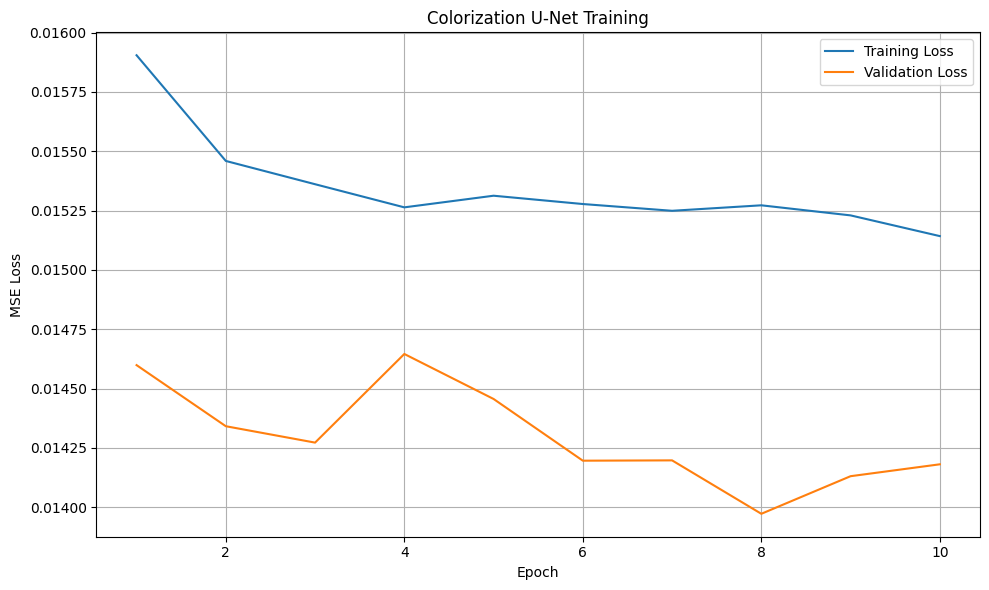

In [46]:
# ============================================================
# STEP 13.1 — COLORIZATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, COLOR_EPOCHS + 1),
    color_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, COLOR_EPOCHS + 1),
    color_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Colorization U-Net Training")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# STEP 13.2 — LOAD BEST COLORIZATION MODEL
# ============================================================

color_model.load_state_dict(
    torch.load(
        best_color_path,
        map_location=DEVICE
    )
)

color_model.eval()

print("Best colorization model loaded.")

Best colorization model loaded.


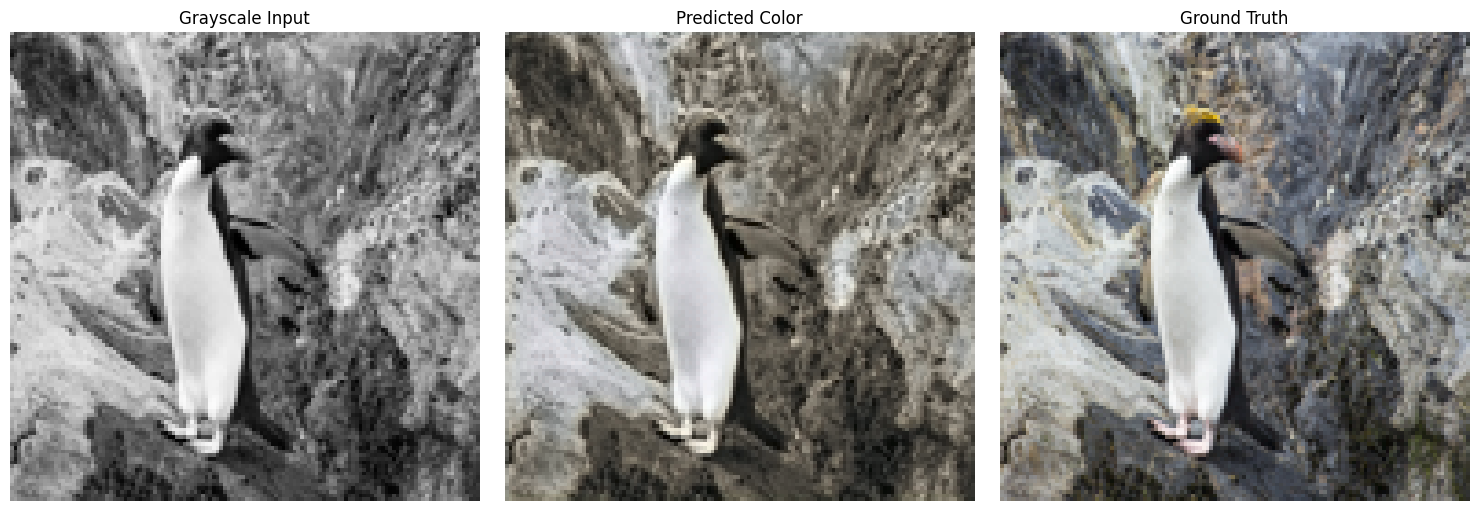

In [48]:
# ============================================================
# STEP 13.3 — COLORIZATION RESULT
# ============================================================

L_batch, ab_batch = next(
    iter(color_val_loader)
)

L_gpu = L_batch.to(DEVICE)

with torch.no_grad():

    predicted_ab = color_model(
        L_gpu
    )

L = L_batch[0].squeeze().numpy()

pred_ab = predicted_ab[0].cpu().numpy()

true_ab = ab_batch[0].numpy()

# ------------------------------------------------------------
# Convert predicted LAB → RGB
# ------------------------------------------------------------

L_cv = (
    L * 255.0
).astype(np.uint8)

pred_ab_cv = (
    pred_ab.transpose(1, 2, 0) * 128.0
    + 128.0
)

pred_ab_cv = np.clip(
    pred_ab_cv,
    0,
    255
).astype(np.uint8)

pred_lab = np.concatenate(
    [
        L_cv[:, :, None],
        pred_ab_cv
    ],
    axis=2
)

pred_rgb = cv2.cvtColor(
    pred_lab,
    cv2.COLOR_LAB2RGB
)

# ------------------------------------------------------------
# Ground truth RGB
# ------------------------------------------------------------

true_ab_cv = (
    true_ab.transpose(1, 2, 0) * 128.0
    + 128.0
)

true_ab_cv = np.clip(
    true_ab_cv,
    0,
    255
).astype(np.uint8)

true_lab = np.concatenate(
    [
        L_cv[:, :, None],
        true_ab_cv
    ],
    axis=2
)

true_rgb = cv2.cvtColor(
    true_lab,
    cv2.COLOR_LAB2RGB
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    L,
    cmap="gray"
)

axes[0].set_title(
    "Grayscale Input"
)

axes[1].imshow(
    pred_rgb
)

axes[1].set_title(
    "Predicted Color"
)

axes[2].imshow(
    true_rgb
)

axes[2].set_title(
    "Ground Truth"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()